## EDA 5: Análisis Exploratorio de los datos

* `Directorio:` ../data/store_zara_data
* `csv:`store_zara.csv

In [2172]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import json
%matplotlib inline

In [2173]:
df_store_zara = pd.read_csv('../data/store_zara_data/store_zara.csv', sep=',')
df_store_zara.head(2)

,brand,url,sku,name,description,price,currency,images,scraped_at,terms,section,error,image_downloads
0,Zara,https://www.zara.com/us/en/basic-puffer-jacket...,272145190-250-2,BASIC PUFFER JACKET,Puffer jacket made of tear-resistant ripstop f...,19.99,USD,['https://static.zara.net/photos///2023/I/0/2/...,2024-02-19T08:50:05.654618,jackets,MAN,NaN,"['e8e4ae57-8b72-44ff-aa5d-84de3ed37d9e', '0cb3..."
1,Zara,https://www.zara.com/us/en/tuxedo-jacket-p0889...,324052738-800-46,TUXEDO JACKET,Straight fit blazer. Pointed lapel collar and ...,169.00,USD,['https://static.zara.net/photos///2024/V/0/1/...,2024-02-19T08:50:06.590930,jackets,MAN,NaN,"['b42b0725-cfe2-4748-af3e-3abe590d83cd', 'ed9c..."


## Generación de dataset: Mujer 

In [2174]:
store_zara_woman = df_store_zara[df_store_zara['section'] == 'WOMAN']
store_zara_woman.head(3)


,brand,url,sku,name,description,price,currency,images,scraped_at,terms,section,error,image_downloads
1120,Zara,https://www.zara.com/us/en/metal-button-struct...,332624848-401-1,METAL BUTTON STRUCTURED BLAZER,Blazer with round collar and long sleeves. Fro...,69.9,USD,['https://static.zara.net/photos///2024/V/0/1/...,2024-02-19T09:02:46.372754,blazers,WOMAN,NaN,"['32fc4d87-c877-4376-8691-04e2dad10ac7', '0f11..."
1121,Zara,https://www.zara.com/us/en/short-textured-jack...,320423576-055-1,SHORT TEXTURED JACKET,Cropped jacket with round neck and long sleeve...,89.9,USD,['https://static.zara.net/photos///2024/V/0/1/...,2024-02-19T09:02:46.875745,blazers,WOMAN,NaN,"['c3c592dd-63f1-4ffa-b13c-4dd845040ca9', '5996..."
1122,Zara,https://www.zara.com/us/en/wool-blend-peplum-k...,318594123-802-2,WOOL BLEND PEPLUM KNIT BLAZER,Blazer made with 89% wool. V-neckline and long...,109.0,USD,['https://static.zara.net/photos///2023/I/0/1/...,2024-02-19T09:02:47.452209,blazers,WOMAN,NaN,"['95663de6-e7dd-4f99-80e0-3b1ad3dcb365', '0ede..."


## Filtrar el conjunto de datos: Calzado Mujer / Calzado Hombre

In [2175]:
zara_woman_shoes = store_zara_woman[store_zara_woman['terms'] == 'shoes']
zara_woman_shoes.head(3)

,brand,url,sku,name,description,price,currency,images,scraped_at,terms,section,error,image_downloads
2639,Zara,https://www.zara.com/us/en/pearl-heeled-slingb...,311302378-098-35,PEARL HEELED SLINGBACKS,Slingback heels with front pearl detail. Point...,79.9,USD,['https://static.zara.net/photos///2023/I/1/1/...,2024-02-19T09:21:05.747353,shoes,WOMAN,NaN,"['79d241c5-2dcc-4fc2-8520-3611fe0be740', 'a462..."
2640,Zara,https://www.zara.com/us/en/leather-ballet-flat...,319457938-002-35,LEATHER BALLET FLATS,Mary Jane style leather ballet flats. Buckled ...,59.9,USD,['https://static.zara.net/photos///2024/V/1/1/...,2024-02-19T09:21:06.245974,shoes,WOMAN,NaN,"['3c5a4b1d-407b-4683-8489-795e1177aa4a', '769a..."
2641,Zara,https://www.zara.com/us/en/high-heel-slingback...,315231501-800-35,HIGH HEEL SLINGBACK PUMPS,Heeled slingbacks with faux patent leather fin...,49.9,USD,['https://static.zara.net/photos///2024/V/1/1/...,2024-02-19T09:21:06.831375,shoes,WOMAN,NaN,"['8f6fa50a-6df1-4d4f-9af5-3dc5b59abc74', 'a497..."


In [2176]:
print(zara_woman_shoes['terms'].unique())

['shoes']


## Seleccion de columnas relevantes en cada conjunto de datos:  zara_woman_shoes

In [2177]:

df_zara_woman_shoes = zara_woman_shoes[['name','description','price','currency','terms','image_downloads']].reset_index(drop=True)

In [2178]:
print(f'Mujer Calzado: {df_zara_woman_shoes.shape}')

Mujer Calzado: (287, 6)


## Mujer: df_zara_woman_shoes

In [2179]:
df_zara_woman_shoes.head(3)

,name,description,price,currency,terms,image_downloads
0,PEARL HEELED SLINGBACKS,Slingback heels with front pearl detail. Point...,79.9,USD,shoes,"['79d241c5-2dcc-4fc2-8520-3611fe0be740', 'a462..."
1,LEATHER BALLET FLATS,Mary Jane style leather ballet flats. Buckled ...,59.9,USD,shoes,"['3c5a4b1d-407b-4683-8489-795e1177aa4a', '769a..."
2,HIGH HEEL SLINGBACK PUMPS,Heeled slingbacks with faux patent leather fin...,49.9,USD,shoes,"['8f6fa50a-6df1-4d4f-9af5-3dc5b59abc74', 'a497..."


In [2180]:
df_zara_woman_shoes.isnull().sum()

name               2
description        2
price              0
currency           0
terms              0
image_downloads    0
dtype: int64

## Revisar registros faltantes en el campo name y description para completarlos en caso de ser viable.

In [2181]:
df_zara_woman_shoes[df_zara_woman_shoes['name'].isnull()]

,name,description,price,currency,terms,image_downloads
13,NaN,NaN,49.9,USD,shoes,"['be82e91e-cd95-4f65-9940-55413188a371', '41ca..."
18,NaN,NaN,49.9,USD,shoes,"['978ad17f-b8f5-4302-bea2-521657049ae4', 'e649..."


In [2182]:
def get_images_json_to_list(x:list):
    json_cadena = x.replace("'", "\"")
    lista_imagenes = json.loads(json_cadena)
    return lista_imagenes


imagenes_fila_13 = get_images_json_to_list(df_zara_woman_shoes.loc[13, 'image_downloads'])
imagenes_fila_18 = get_images_json_to_list(df_zara_woman_shoes.loc[18, 'image_downloads'])

In [2183]:
def show_images(lista_imagenes):
    """ Funcion para mostrar las imagenes"""
    fig, axs = plt.subplots(nrows=1, ncols=len(lista_imagenes), figsize=(20,5))
    for i, image in enumerate(lista_imagenes):
        image_path = "../data/store_zara_data/images/zara/" + str(image) + ".jpg"
        image = Image.open(image_path).convert("RGB")
        axs[i].imshow(image)
        axs[i].axis('off')
    plt.tight_layout() 
    plt.show()

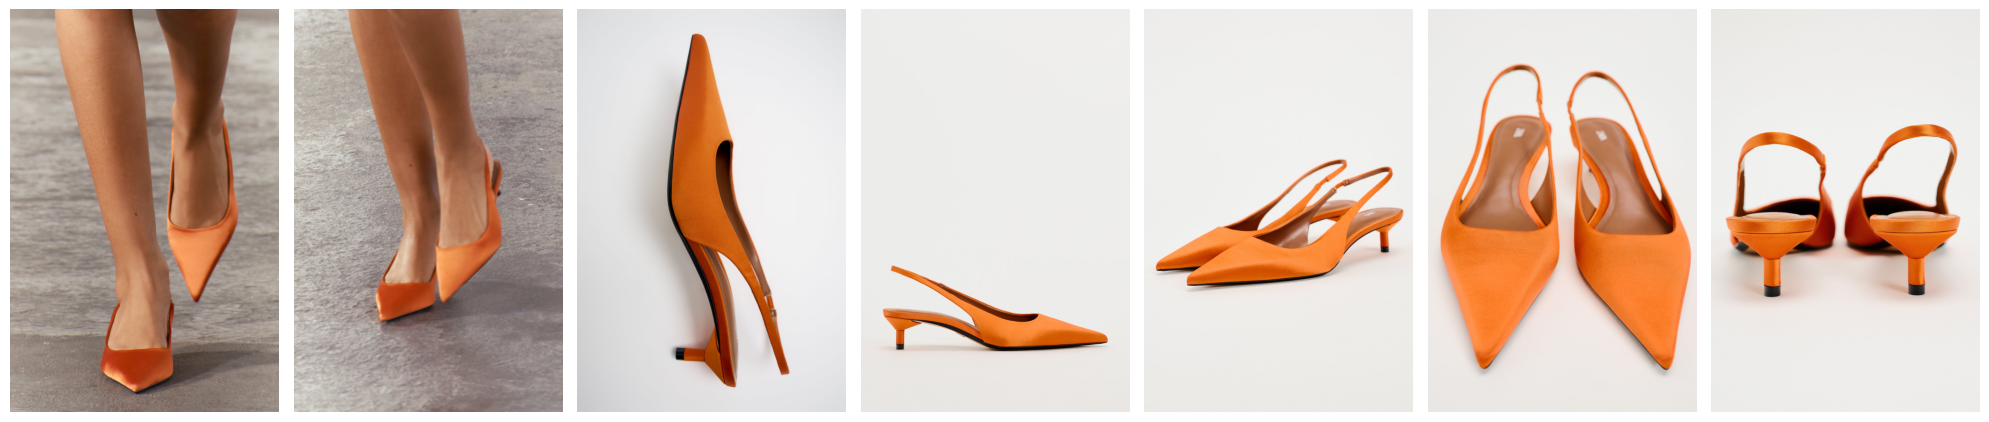

In [2184]:

show_images(imagenes_fila_13)

In [ ]:
show_images(imagenes_fila_18)

## Acciones: Completar los valores faltantes de las filas 13 y 18 en los campos name y description con información recopilada en:
https://www.telier.app/UY/mujer/producto?productId=WmFyYVVZLTM2NDE3NzE1OC0wNzA=

In [2186]:
df_zara_woman_shoes.loc[13, 'name'] = 'FABRIC SHOES WITH THIN HEELS'
df_zara_woman_shoes.loc[13, 'description'] = 'Fabric sandals with thin heels. Strap on the back. Pointed beak.Heel height: 5 cm.'
df_zara_woman_shoes.loc[13, ['name', 'description']]

name                                FABRIC SHOES WITH THIN HEELS
description    Fabric sandals with thin heels. Strap on the b...
Name: 13, dtype: object

In [2187]:
df_zara_woman_shoes.loc[18,'name'] = 'FABRIC SHOES WITH THIN HEELS'
df_zara_woman_shoes.loc[18, 'description'] = 'Fabric sandals with thin heels. Strap on the back. Pointed beak.Heel height: 5 cm.'
df_zara_woman_shoes.loc[18, ['name', 'description']]

name                                FABRIC SHOES WITH THIN HEELS
description    Fabric sandals with thin heels. Strap on the b...
Name: 18, dtype: object

## Se aplica la misma lógica que el conjunto de datos de calzado hombre para quedarnos con la última palabra del campo name para crear un campo nuevo   que indique una categoria general de tipo de calzado para cada registro.

In [2188]:
def get_type_od_shoes(x:str):
    words = x.split(' ')
    # Obtener el ultimo elemento de la lista
    return words[-1]

# Registros de zapatos con edicion limitada. 
df_zara_woman_shoes['category'] = df_zara_woman_shoes['name'].apply(get_type_od_shoes)

In [2189]:
df_zara_woman_shoes['category'].unique()

d:\programas\miniconda\envs\ia_tfg\Lib\site-packages\IPython\core\displayhook.py:281: UserWarning: Output cache limit (currently 1000 entries) hit.
Flushing oldest 200 entries.
  warn('Output cache limit (currently {sz} entries) hit.\n'


array(['SLINGBACKS', 'FLATS', 'PUMPS', 'SHOES', 'BOW', 'SANDALS', 'JANES',
       'MULES', 'HEELS', 'CLOGS', 'LOAFERS', 'cm)', 'MULE', 'BOOTS',
       'SNEAKERS', 'SLIDES', 'MOCCASINS', 'EDITION', 'WEDGES', 'TASSELS',
       'STRAP', 'HEEL', 'COLLECTION', 'PUMP', 'BUCKLE', 'SOLES', 'ZIPPER',
       'EMBELLISHMENT', 'JUMPSUIT'], dtype=object)

### Se observan valores en el campo category no asociados a calzado.  Se procede a una analisis mas detallado.

In [2190]:
df_zara_woman_shoes[df_zara_woman_shoes['category']=='SLINGBACKS']

,name,description,price,currency,terms,image_downloads,category
0,PEARL HEELED SLINGBACKS,Slingback heels with front pearl detail. Point...,79.9,USD,shoes,"['79d241c5-2dcc-4fc2-8520-3611fe0be740', 'a462...",SLINGBACKS
8,HEELED SHINY MESH SLINGBACKS,High heel slingbacks with shiny mesh fabric. \...,69.9,USD,shoes,"['642ace63-0317-4f5e-80b8-a6f8f5dffd9e', '7b92...",SLINGBACKS
37,PATENT EFFECT HEELED SLINGBACKS,Patent effect high heel slingbacks. Buckled ba...,49.9,USD,shoes,"['026a3401-94a1-457e-9201-46f4f3b6ee2c', '8256...",SLINGBACKS
71,FABRIC KITTEN HEEL SLINGBACKS,Fabric slingbacks. Kitten heels. Pointed toe. ...,49.9,USD,shoes,"['b2d38afb-aa46-4bf1-9101-756296e2cfb5', '043b...",SLINGBACKS
84,STRAPPY HEELED SLINGBACKS,Heeled slingback shoes. Thin straps with rings...,49.9,USD,shoes,"['51e5cff7-7162-44fe-818a-04b78d2f16b3', 'e5db...",SLINGBACKS
117,METALLIC HEELED SLINGBACKS,Slingback block heel shoes with metallic effec...,49.9,USD,shoes,"['4c56596d-bca5-424d-bc09-ced6c65ad70a', 'd1ca...",SLINGBACKS


In [2191]:
df_zara_woman_shoes[df_zara_woman_shoes['category']=='FLATS']

,name,description,price,currency,terms,image_downloads,category
1,LEATHER BALLET FLATS,Mary Jane style leather ballet flats. Buckled ...,59.9,USD,shoes,"['3c5a4b1d-407b-4683-8489-795e1177aa4a', '769a...",FLATS
41,FAUX PATENT LEATHER BALLET FLATS,Mary Jane style shoes with faux patent leather...,49.9,USD,shoes,"['5c16b996-7beb-45ad-88c9-c7ca5eb0560e', 'b05d...",FLATS
45,SOFT LEATHER SLINGBACK FLATS,Soft leather slingback flats. Buckled wide bac...,69.9,USD,shoes,"['17747d8b-2d4c-43e1-b431-9af4a1088f73', 'ad70...",FLATS
57,SHINY MESH BALLET FLATS,Mesh ballet flats with shiny detail. \n\nSole ...,69.9,USD,shoes,"['d62c8d3e-5d29-4075-8baa-75c262c46a89', 'e795...",FLATS
89,PATENT EFFECT FLATS,Faux patent flats. High vamp. Squared toe.\n\n...,49.9,USD,shoes,"['0eec2471-4f31-4b64-9c03-f1f7ea71735f', '5cf6...",FLATS
90,SOFT LEATHER SLINGBACK FLATS,Soft leather slingback flats. Buckled wide bac...,69.9,USD,shoes,"['222cd58c-e457-435d-a358-3fa198cf0539', '209f...",FLATS
120,LEATHER BALLET FLATS,Mary Jane style leather ballet flats. Buckled ...,59.9,USD,shoes,"['4d797d24-ba84-4a32-a3a4-8d979042fdc9', '492b...",FLATS
130,VELVET BALLET FLATS,Velvet ballet flats. Buckle strap fastening at...,59.9,USD,shoes,"['38bda606-6e17-47ef-a98a-11fa494fb64f', '2418...",FLATS
156,LACE UP VELVET BALLET FLATS,Velvet ballet flats. Ankle tie closure. \n\nSo...,59.9,USD,shoes,"['faf1b6cb-ef40-4f3a-bb8e-a5a99330e2b5', '4a1a...",FLATS
179,FAUX FUR BALLET FLATS,Faux fur ballet flats. Double straps on the in...,49.9,USD,shoes,"['2a7697e7-a90a-4c74-a96b-2cd84ef0b04e', 'e975...",FLATS


In [2192]:
df_zara_woman_shoes[df_zara_woman_shoes['category']=='PUMPS']

,name,description,price,currency,terms,image_downloads,category
2,HIGH HEEL SLINGBACK PUMPS,Heeled slingbacks with faux patent leather fin...,49.9,USD,shoes,"['8f6fa50a-6df1-4d4f-9af5-3dc5b59abc74', 'a497...",PUMPS
3,HIGH HEEL SLINGBACK PUMPS,Heeled faux patent leather slingbacks. Back st...,49.9,USD,shoes,"['afe05bc6-32c5-4491-960a-2b0e650a8d68', 'deb5...",PUMPS
85,CRACKLED HEELED PUMPS,Crackled effect slingback heels. Front straps ...,49.9,USD,shoes,"['a28c3b25-1cd6-456b-a665-ad43a34eed9f', '866a...",PUMPS
206,BLOCK HEEL BOW PUMPS,Block heel pumps. Faux patent leather finish. ...,49.9,USD,shoes,"['d65026f0-019c-4b4b-93af-15a046e316ad', '1915...",PUMPS


In [2193]:
# La categoria shoes obtenida al final  de algunos regsitros en el campo name es muy general con respecto al resto de categorias.
df_zara_woman_shoes[df_zara_woman_shoes['category']=='SHOES']

,name,description,price,currency,terms,image_downloads,category
4,BLOCK HEEL SLINGBACK SHOES,Slingback block heel pumps. Front strap with b...,49.90,USD,shoes,"['4b68114f-4b9f-4810-96c7-dadea539246b', '7c89...",SHOES
11,BRUSHED EFFECT FLAT SHOES,Flat Mary Janes with brushed effect. Buckled s...,69.90,USD,shoes,"['8339bbef-cbd5-4c33-a173-8546175e4f58', 'd3bb...",SHOES
16,BOW TRIM VELVET SLINGBACK SHOES,Heeled velvet slingback shoes. Bow detail at f...,69.90,USD,shoes,"['baf6e38c-734b-4380-9f95-359d56dd4573', 'f9fa...",SHOES
17,LACE-UP FLAT LEATHER SHOES,Flat leather derby shoes. Loafer style vamp. L...,69.90,USD,shoes,"['379bebec-9ebe-4bbf-9261-ccd145587499', '5e92...",SHOES
33,FAUX PATENT LEATHER HEELED SHOES,Heeled faux patent leather shoes. Ankle strap ...,49.90,USD,shoes,"['c49e7c53-6cbb-4ceb-afe7-128d532c23f8', '6cfc...",SHOES
40,FLAT SHOES,Flat loafers. Wrinkled faux patent leather fin...,49.90,USD,shoes,"['5e13fb50-4764-47d5-8007-a57cb42cec6a', '3eaa...",SHOES
43,HEELED MESH SHOES,High heel mesh fabric pumps. Pointed toe. \n\n...,49.90,USD,shoes,"['b651ec49-3c0d-4706-9895-8627f2d5dc2f', '87ea...",SHOES
44,BUCKLED HEELED SHOES,High heel faux patent leather shoes. Buckled s...,59.90,USD,shoes,"['281d9613-0ad8-4e0b-be88-660ad862c080', 'ae56...",SHOES
46,SLINGBACK BUCKLED FLAT SHOES,Flat slingback shoes with buckles. Back strap....,49.90,USD,shoes,"['735637c5-b0ba-4886-8630-d8c8314f5f2d', 'e59f...",SHOES
47,STRAPPY HEELED SHOES,Mary Jane shoes with block heels. Faux patent ...,49.90,USD,shoes,"['37836c2a-7ab3-4fbf-8f3e-81f5a6de89df', '1351...",SHOES


In [2194]:
# En este caso BOW hace referencia a lazo. La categoria general es en este caso seria SLINGBACK HEELS y HEELED MULES
df_zara_woman_shoes[df_zara_woman_shoes['category']=='BOW']

,name,description,price,currency,terms,image_downloads,category
5,SLINGBACK HEELS WITH BOW,Faux patent leather high heel slingbacks. Bow ...,59.9,USD,shoes,"['e7c0f6cf-988f-4b02-ab62-0fa223177eb8', '2317...",BOW
7,SLINGBACK HEELS WITH BOW,Slingback heels. Bow detail at front. Back str...,49.9,USD,shoes,"['1633e8bd-2027-4b68-a600-e4a575ac85be', '51e4...",BOW
155,HEELED MULES WITH BOW,Slingback heels with faux patent leather. Fron...,49.9,USD,shoes,"['f74a8b0f-8335-494d-9e54-6dfdecf852df', 'b80d...",BOW


In [2195]:
df_zara_woman_shoes[df_zara_woman_shoes['category']=='SANDALS']

,name,description,price,currency,terms,image_downloads,category
6,FLAT BUCKLED SANDALS,Flat sandals with buckled straps. Rounded toe....,49.90,USD,shoes,"['c8749497-cf4e-4fd4-9d02-a937e8a25bf7', '74ca...",SANDALS
9,MESH BOW SANDALS,High heel fabric sandals in mesh fabric. Bow d...,49.90,USD,shoes,"['9e145f0a-386f-408d-b12e-4890c0911254', '740e...",SANDALS
20,ANIMAL PRINT FLAT SANDALS,Flat animal print sandals. Wide buckles. Round...,79.90,USD,shoes,"['3fb69453-c18c-4661-a25a-2fb39f1f2b4e', '321f...",SANDALS
23,RING DETAIL VINYL HEELED SANDALS,Heeled vinyl sandals. Wide front straps. Ring ...,49.90,USD,shoes,"['e10ce80f-70b1-4162-9827-7e9f6b06993c', 'd9cb...",SANDALS
28,ANIMAL PRINT HEELED SANDALS,Heeled sandals. Animal print upper. Thin front...,49.90,USD,shoes,"['206f5f68-c3cd-407d-993e-224615de091e', '3006...",SANDALS
35,RHINESTONE VINYL HIGH HEEL SANDALS,High heel sandals in vinyl with rhinestone det...,69.90,USD,shoes,"['37dc9bb2-5bc2-4944-baa4-8b7908b9c9d1', '3719...",SANDALS
38,FLAT LEATHER SANDALS,Flat leather sandals with toe-post. Round toe....,59.90,USD,shoes,"['077be311-8675-43c3-a390-abd914aa7a42', '2663...",SANDALS
49,CHUNKY HEELED PLATFORM SUEDE SANDALS,Suede sandals. High heels with platform. Buckl...,69.90,USD,shoes,"['d0d829a4-8060-4dca-b6a7-0fa932b13932', 'cdb8...",SANDALS
52,FLAT CROSSED-STRAP SANDALS,Flat sandals with crossed bands. \n\nSole heig...,49.90,USD,shoes,"['9754f2cc-8f3b-4dd2-896a-47cc8a800030', '750f...",SANDALS
56,BOW TRIM HEELED VINYL SANDALS,Heeled vinyl sandals. Front embellished bow. B...,69.90,USD,shoes,"['3f46602a-23e7-407b-b16b-8ce681102510', '1d44...",SANDALS


In [2196]:
## La categoria Janes no seria la categoria adecuada. Es tipo de calzado es mary jane.
df_zara_woman_shoes[df_zara_woman_shoes['category']=='JANES']

,name,description,price,currency,terms,image_downloads,category
10,FLAT MESH MARY JANES,Flat Mary Janes in mesh fabric. Buckled ankle ...,49.9,USD,shoes,"['3e9c90aa-9efc-4713-84f4-43bf59b237ff', 'ef57...",JANES
24,PATENT EFFECT FAUX LEATHER MARY JANES,Flat Mary Jane style shoes with faux patent le...,39.9,USD,shoes,"['2f4acd7e-7db6-4384-bbe5-ca9fcd717e66', '4ac3...",JANES
70,PATENT EFFECT FAUX LEATHER MARY JANES,Mary Jane style shoes with faux patent leather...,49.9,USD,shoes,"['1e46cef5-724e-420f-b3a0-1b7297530cdf', 'b12b...",JANES
81,STRAPPY HEELED MARY JANES,Block heel Mary Jane shoes. Faux patent leathe...,49.9,USD,shoes,"['1ede05b8-5b49-4476-994c-4fe8389dc760', '65ab...",JANES
140,MESH HEELED MARY JANES,Block heel Mary Jane shoes. Double strap at in...,49.9,USD,shoes,"['ca150412-4441-45c0-affb-f00b70151441', 'b4bd...",JANES
172,STRAPPY HEELED MARY JANES,Block heel Mary Jane shoes. Faux patent leathe...,49.9,USD,shoes,"['54162886-8364-471d-b610-ba016d56ca69', '96f0...",JANES
181,BUCKLE MARY JANES,Mary Jane shoes. Wide strap with buckle. Squar...,49.9,USD,shoes,"['878de126-269a-4cba-a4e9-6b6ba86a8808', '6ff4...",JANES
182,BUCKLED LUG SOLE MARY JANES,Mary Jane style shoes with faux patent leather...,49.9,USD,shoes,"['2ea71b21-2132-4ce2-85e0-0e9fc0ffc522', '1204...",JANES


In [2197]:
df_zara_woman_shoes[df_zara_woman_shoes['category']=='MULES']

,name,description,price,currency,terms,image_downloads,category
12,FABRIC MULES,Slingback flats with patent leather effect fin...,49.9,USD,shoes,"['6c553070-a0cb-40b4-9a38-fb2e21de2fe2', '0e5d...",MULES
14,FAUX PATENT LEATHER HEELED MULES,Heeled mules with faux patent leather finish. ...,49.9,USD,shoes,"['8857c01f-0d9a-4d36-8924-f318915b7d91', '6ebe...",MULES
19,MESH MULES,Flat mules in mesh fabric. Buckled back strap....,49.9,USD,shoes,"['151bbba7-b8c1-417f-b2f9-3640036225c6', 'a092...",MULES
31,HIGH HEEL MULES,High heel open back mules. \n\nHeel height: 3....,69.9,USD,shoes,"['a2db7e53-ac4e-4cc9-aa6d-b83d518e93dd', 'bdf6...",MULES
34,FLAT MULES,Flat mules. Satin effect fabric. Buckled ankle...,49.9,USD,shoes,"['b907e091-67a5-4297-ae77-89ec5592a774', '39e8...",MULES
64,BUCKLED HEELED MULES,Heeled mules. Front wide strap with buckle. Po...,49.9,USD,shoes,"['39a53972-777e-46b5-ad5f-240d7338f33c', 'c4a3...",MULES
124,SHINY FABRIC MULES,Mesh effect fabric mules. Shiny upper. Thin he...,69.9,USD,shoes,"['b9ebc542-3082-412f-8d5d-47980be96daa', '19f3...",MULES
129,BOW TRIM VELVET MULES,Velvet kitten heel mules. Bow detail at front....,49.9,USD,shoes,"['af97262d-f07c-40c3-9596-58dfcee0abda', 'a5e5...",MULES
146,SHINY WOVEN MULES,Flat mules with shiny woven upper. \n\nSole he...,59.9,USD,shoes,"['54c4a9eb-9543-40e4-80d8-7ab0092ecced', '8d54...",MULES
160,INSTEP STRAP HEELED MULES,Heeled mules. Buckled strap detail at instep. ...,59.9,USD,shoes,"['fc3272a5-99c6-482b-8b31-1bded5164eef', '68af...",MULES


In [2198]:
df_zara_woman_shoes[df_zara_woman_shoes['category']=='HEELS']

,name,description,price,currency,terms,image_downloads,category
13,FABRIC SHOES WITH THIN HEELS,Fabric sandals with thin heels. Strap on the b...,49.9,USD,shoes,"['be82e91e-cd95-4f65-9940-55413188a371', '41ca...",HEELS
18,FABRIC SHOES WITH THIN HEELS,Fabric sandals with thin heels. Strap on the b...,49.9,USD,shoes,"['978ad17f-b8f5-4302-bea2-521657049ae4', 'e649...",HEELS
74,SLINGBACK STRAPPY LEATHER KITTEN HEELS,Slingback kitten heels with faux patent leathe...,49.9,USD,shoes,"['c230529c-3424-4baa-9645-636d5017adfe', '7938...",HEELS
107,ANIMAL PRINT SLINGBACK HEELS,Animal print heeled slingbacks. Buckled ankle ...,49.9,USD,shoes,"['152595d4-db60-4f8b-8179-83a091cf55e9', 'c2a1...",HEELS
134,BLOCK HEEL HIGH HEELS,Block heel pumps. Tortoiseshell heels. Pointed...,49.9,USD,shoes,"['db10fb46-3dec-4706-b6e3-0287f87b9ccd', 'b017...",HEELS
220,RHINESTONE OPEN BACK HEELS,High heel slingbacks in mesh fabric. Thin cros...,69.9,USD,shoes,"['2de3aecf-d8ad-4b6b-a13c-a9a176e4e95c', '2b61...",HEELS
225,STILETTO HEELS,Heeled pumps. Thin heel. Pointed toe.\n\nHeel ...,49.9,USD,shoes,"['3ddfced9-0c02-45b6-ad3c-7bc7a6fe6a51', '90e0...",HEELS


In [2199]:
df_zara_woman_shoes[df_zara_woman_shoes['category']=='CLOGS']

,name,description,price,currency,terms,image_downloads,category
15,FAUX FLEECE CLOGS,Flat faux shearling clogs. Buckled strap detai...,69.9,USD,shoes,"['e24b9a27-124c-4bb5-8992-83abd2558f2f', '4c29...",CLOGS
27,BUCKLED STRAP CLOGS,Chunky flat mule clogs. Buckled wide back stra...,49.9,USD,shoes,"['d1562df2-f596-4343-a51f-f235548688d4', '5e92...",CLOGS
32,BUCKLED SUEDE CLOGS,Flat suede clogs. Buckle detail. \n\nSole heig...,69.9,USD,shoes,"['15638620-f87c-43e9-a41a-dfcc6ce5ef32', '4ff9...",CLOGS
39,SQUARE TOE LEATHER CLOGS,Leather clogs. Chunky sole and wood effect blo...,139.0,USD,shoes,"['97c64014-4134-431e-813b-f16ae7aba626', '5468...",CLOGS
142,FLAT BUCKLED CLOGS,Flag open back clogs. Metal buckle detail. \n\...,49.9,USD,shoes,"['1b054f6c-0af1-4ba5-92af-4a5f06960ce7', 'a3a5...",CLOGS
167,DISTRESSED EFFECT BLOCK HEEL CLOGS,Clogs with block heel and distressed effect. P...,69.9,USD,shoes,"['d5262327-88ee-40e6-b333-04327d824f57', '3e11...",CLOGS
218,FAUX FUR LINED SUEDE CLOGS,Flat suede clogs. Metal buckle at side and fau...,69.9,USD,shoes,"['b18777b0-9401-4b44-90c0-8a10fecbd4f0', '9d88...",CLOGS
222,RUBBERIZED CLOGS,Rubberized clogs. Chunky soles. Rounded toe.\n...,59.9,USD,shoes,"['430be088-ed73-443b-9c03-84864e97b82a', '7631...",CLOGS
257,LEATHER BIKER CLOGS,Open back leather clogs. Buckled strap detail....,109.0,USD,shoes,"['3381c4a2-63a5-4b98-b2cd-fc5c165bbfd7', '7232...",CLOGS
267,ANIMAL PRINT BLOCK HEEL CLOGS,Clogs with block heel and animal print. Pointe...,69.9,USD,shoes,"['6c9f83eb-35c2-452a-95c4-a715c8c9a2bb', '4deb...",CLOGS


In [2200]:
df_zara_woman_shoes[df_zara_woman_shoes['category']=='LOAFERS']

,name,description,price,currency,terms,image_downloads,category
21,EMBELLISHED VELVET LOAFERS,Flat velvet loafers. Front metal embellishment...,49.9,USD,shoes,"['3e841001-70f0-485e-a170-cc9236f361cc', '6447...",LOAFERS
29,BLOCK HEEL CROC LOAFERS,Block heel loafers with croc embossing. High v...,59.9,USD,shoes,"['76038b79-76aa-4412-9496-e2a43fda585b', 'a422...",LOAFERS
30,LEATHER LOAFERS,Flat leather loafers. High vamp and saddle. Ro...,69.9,USD,shoes,"['a6e20122-1fbe-45a4-8f65-f6c1120b93f4', '40f5...",LOAFERS
61,BUCKLED SOFT LEATHER LOAFERS,Flat loafers in soft leather. Front metal buck...,69.9,USD,shoes,"['d6546549-c638-4110-b5c2-35e11805e56d', 'b1d5...",LOAFERS
69,FAUX PATENT LEATHER FLAT PENNY LOAFERS,Low heel penny loafers with faux patent leathe...,49.9,USD,shoes,"['ff16c18c-0e08-480f-8d4b-34f9dd5dbc91', '2fba...",LOAFERS
82,STUDDED LOAFERS,Patent effect loafers. Upper with stud detail....,69.9,USD,shoes,"['cb13b30b-b9d6-4ab1-aeab-a3110ed9c1a4', 'e12a...",LOAFERS
127,DISTRESSED EFFECT LUG SOLE LOAFERS,Flat loafers with distressed look. Lug soles. ...,49.9,USD,shoes,"['805b8e47-828c-4a1f-a9c8-d02d0c141091', '63c4...",LOAFERS
135,ANIMAL PRINT LOAFERS,Flat animal print leather penny loafers. High ...,49.9,USD,shoes,"['d886907d-42b4-48ce-ab61-aca6c8375f78', '5046...",LOAFERS
138,CONTRAST LEATHER LOAFERS,Flat leather loafers. Contrasting upper. Ruchi...,89.9,USD,shoes,"['c2a74260-9793-4b70-bc06-5df7284df9b1', 'c840...",LOAFERS
162,FLAT LEATHER LOAFERS,Flat leather loafers. High vamp and saddle. \n...,109.0,USD,shoes,"['dfe2729f-4296-43bd-9cad-7a528dd01275', 'd8e2...",LOAFERS


In [2201]:
# Añadir 's' a mule, para que pertenerca a la categoría mules
df_zara_woman_shoes[df_zara_woman_shoes['category']=='MULE']

,name,description,price,currency,terms,image_downloads,category
25,DISTRESSED EFFECT HEELED MULE,Open back heeled mules with distressed effect....,59.9,USD,shoes,"['88cab8f7-dabb-4752-a70f-36a38efeceb0', '4126...",MULE


In [2202]:
df_zara_woman_shoes[df_zara_woman_shoes['category']=='BOOTS']

,name,description,price,currency,terms,image_downloads,category
26,STRAIGHT SHAFT KNEE HIGH HEELED BOOTS,Heeled knee high boots. Thin heel. Straight sh...,109.00,USD,shoes,"['5b9f575e-0723-4aed-a8c5-b03474960912', '9818...",BOOTS
42,LEATHER CHELSEA ANKLE BOOTS,Flat ankle boots in leather. Side elastic gori...,109.00,USD,shoes,"['98d3d2bb-c36c-4da6-95b5-29f6fcddd5dc', 'ef97...",BOOTS
53,BLOCK HEEL LEATHER GAITER BOOTS,Knee high leather boots. Gaiter detail. Block ...,159.00,USD,shoes,"['fb911b8a-a1f6-4520-9d34-f6a67879b916', '8705...",BOOTS
60,FABRIC GAITER BOOTS,Tall fabric boots with gaiter detail. Pointed ...,89.90,USD,shoes,"['5ff2d308-c69c-4500-b815-d0b65c0444f1', '0120...",BOOTS
73,HEELED LEATHER KNEE HIGH BOOTS,Heeled leather knee high boots. Thin heel. Poi...,169.00,USD,shoes,"['39565516-1832-4e7f-8db9-800561d7937e', '6598...",BOOTS
...,...,...,...,...,...,...,...
281,LEATHER BIKER BOOTS,Flat biker ankle boots in leather. Buckled str...,49.99,USD,shoes,"['193072de-cd94-4677-b8c1-8ae3f8182e8d', '0805...",BOOTS
282,LOW HEEL BIKER ANKLE BOOTS,Flat moto ankle boots. Buckle detail with stra...,49.99,USD,shoes,"['1fba27bd-aa79-49c3-8190-2f7c788fe068', 'b838...",BOOTS
283,OPEN TOE FABRIC ANKLE BOOTS,High heel fabric ankle boots. Fitted upper. Op...,35.99,USD,shoes,"['934d0980-eaf2-4b0b-964f-91cd16ecde04', 'a4fd...",BOOTS
284,FLAT BUCKLED ANKLE BOOTS,Basic flat ankle boot with buckle details. Rou...,39.99,USD,shoes,"['afb30bf2-9da9-47a9-8acc-c4d9f3bed3f4', 'c663...",BOOTS


In [2203]:
df_zara_woman_shoes[df_zara_woman_shoes['category']=='SNEAKERS']

,name,description,price,currency,terms,image_downloads,category
36,TEXTURED RUNNING SNEAKERS,Running style sneakers in a combination of tex...,49.9,USD,shoes,"['771cb3c7-9dad-44f7-a89d-a40b1e1bf4b9', '1963...",SNEAKERS
62,SNEAKERS,Fabric running shoes. Rubberized lug sole. Lac...,69.9,USD,shoes,"['807a55f9-c793-4438-89ab-2a515cc03fcb', 'a1b4...",SNEAKERS
68,CASUAL ATHLETIC SNEAKERS,Casual sneakers with leather details. Contrast...,49.9,USD,shoes,"['bdb9cfb6-fd31-4fa2-b686-64d6d4b1e0f3', 'cdec...",SNEAKERS
77,SNEAKERS,Running shoes. Chunky wide soles. Lace-up clos...,69.9,USD,shoes,"['32621abb-787c-46ed-8d22-8e4a1fc93043', '4faa...",SNEAKERS
86,ATHLETIC PLATFORM SNEAKERS,Sneakers with platform soles. Lace-up closure....,49.9,USD,shoes,"['c3b94565-70af-4da9-9ed3-94ee20903dbc', 'd14c...",SNEAKERS
87,FLATFORM SNEAKERS,Sneakers with flatform soles. Lace-up closure....,35.9,USD,shoes,"['44e77942-8cba-47c5-b203-13283c09a159', '00a2...",SNEAKERS
123,METALLIC RUNNING SNEAKERS,Running sneakers with metallic effect. Contras...,49.9,USD,shoes,"['4731d09c-01b5-4ffd-9b1d-78bf55d20e83', '048c...",SNEAKERS
141,CASUAL NYLON SNEAKERS,Casual sneakers in nylon with leather details....,49.9,USD,shoes,"['7d4a0252-a18e-43bd-b061-0d2a601e5887', '8b1c...",SNEAKERS
148,CONTRASTING DETAIL RUNNING SNEAKERS,Running style athletic sneakers with contrasti...,69.9,USD,shoes,"['66bc075b-d7e8-4462-8844-a933ae62f4d0', '1740...",SNEAKERS
149,SNEAKERS,Running style sneakers with color detail at ba...,69.9,USD,shoes,"['7ca258af-6ada-468a-9329-fbed5a30670c', 'e116...",SNEAKERS


In [2204]:
# Unificar categoria cambiar slides por sandals
df_zara_woman_shoes[df_zara_woman_shoes['category']=='SLIDES']

,name,description,price,currency,terms,image_downloads,category
55,FLAT FLOWER SLIDES,Flat sandals with shiny mesh flower details. T...,49.9,USD,shoes,"['630d6984-2863-47ce-aabc-f16cae671254', '3638...",SLIDES


In [2205]:
df_zara_woman_shoes[df_zara_woman_shoes['category']=='MOCCASINS']

,name,description,price,currency,terms,image_downloads,category
67,TASSELED MOCCASINS,Flat loafers. Front tassels. High vamp.\n\nSol...,49.9,USD,shoes,"['a193ceaa-b512-40b7-9821-7db752680a99', '5b1a...",MOCCASINS
189,TASSELED MOCCASINS,Flat loafers with faux patent leather. Front t...,49.9,USD,shoes,"['6b29d132-fd49-4df3-8a3f-452419353b79', '6d9c...",MOCCASINS


In [2206]:
# Limited ediction no es una categoria de calzado como tal, se añadira un campo especifico para calzado con edicion limitada.
df_zara_woman_shoes[df_zara_woman_shoes['category']=='EDITION']

,name,description,price,currency,terms,image_downloads,category
75,RUCHED OPEN BACK LEATHER SHOES LIMITED EDITION,Slingback leather pumps with ruched effect. Ba...,129.0,USD,shoes,"['33006d44-fe99-4bdf-ad44-66ca3085e157', '942e...",EDITION
112,FLOWER SLINGBACK SHOES LIMITED EDITION,Heeled vinyl slingbacks. Front flower detail. ...,149.0,USD,shoes,"['a2cf7816-8793-4c3a-8b43-903fe815c6f4', 'f86a...",EDITION
251,RUCHED SOFT LEATHER BOOTS LIMITED EDITION,High shaft soft leather boots with ruched effe...,299.0,USD,shoes,"['779f6894-c9f1-4198-b91a-21d1bec18a28', 'a3a5...",EDITION


In [2207]:
df_zara_woman_shoes[df_zara_woman_shoes['category']=='WEDGES']

,name,description,price,currency,terms,image_downloads,category
118,CONTRAST LACE-UP WEDGES,Slingback wedges. Upper in a combination of ma...,69.9,USD,shoes,"['4018fcb8-ecd2-405f-ab28-99894ba76ebf', '413f...",WEDGES


In [2208]:
# Tassels no es la categoria correcta, debería ser MOCASSINS
df_zara_woman_shoes[df_zara_woman_shoes['category']=='TASSELS']

,name,description,price,currency,terms,image_downloads,category
119,SPLIT LEATHER MOCCASINS WITH TASSELS,Flat suede penny loafers. Front tassels.\n\nSo...,69.9,USD,shoes,"['a429325a-6068-4ca3-be45-63e5d4680a22', '9661...",TASSELS


In [2209]:
# STRAP no es la categoria correcta, debería ser PUMPS
df_zara_woman_shoes[df_zara_woman_shoes['category']=='STRAP']

,name,description,price,currency,terms,image_downloads,category
125,HEELS WITH ANKLE STRAP,Heeled slingback pumps. Pointed toe. Buckled a...,69.9,USD,shoes,"['d2f9913c-803d-4545-b8be-3ca42141cce6', '22e7...",STRAP
196,HEELS WITH ANKLE STRAP,Heeled pumps. Buckled ankle strap closure. Poi...,59.9,USD,shoes,"['30845999-ec5d-4ad0-9471-d24acfc66c16', 'a5c9...",STRAP
232,HEELS WITH ANKLE STRAP,Heeled pumps. Block heels. Pointed toe. Buckle...,59.9,USD,shoes,"['15088ac5-289e-4bc2-8ad2-b1053871fe32', 'a8ff...",STRAP


In [2210]:
# HEEL no es la categoria correcta, debería ser BOOTS
df_zara_woman_shoes[df_zara_woman_shoes['category']=='HEEL']

,name,description,price,currency,terms,image_downloads,category
128,FABRIC ANKLE BOOT WITH GEOMETRIC HEEL,Stretch fabric ankle boots. High geometrical h...,49.9,USD,shoes,"['bccbc9e1-42b8-471a-b609-017625d08259', '82e2...",HEEL


In [2211]:
# Añadir 's' a pump, para que pertenerca a la categoría pumps
df_zara_woman_shoes[df_zara_woman_shoes['category']=='PUMP']

,name,description,price,currency,terms,image_downloads,category
157,PINSTRIPE HEELED PUMP,Pinstripe print heeled shoes. Thin heel. Point...,49.9,USD,shoes,"['a0400732-5820-4abf-a4ed-1d391b5886bf', '5c58...",PUMP


In [2212]:
# BUCKLE no es la categoria correcta, debería ser BOOTS
df_zara_woman_shoes[df_zara_woman_shoes['category']=='BUCKLE']

,name,description,price,currency,terms,image_downloads,category
176,HEELED ANKLE BOOTS WITH BUCKLE,High heeled ankle boots. Buckle detail at fron...,59.9,USD,shoes,"['908bd4cb-617d-4c9c-804d-ce29923cb8fb', '79de...",BUCKLE


In [2213]:
# SOLES no es la categoria correcta, debería ser BOOTS
df_zara_woman_shoes[df_zara_woman_shoes['category']=='SOLES']

,name,description,price,currency,terms,image_downloads,category
187,HEELED BOOTIES WITH LUG SOLES,Heeled ankle boots with lug sole and stretch s...,49.9,USD,shoes,"['a2518cf6-1b30-4085-862a-81c591db422c', 'b473...",SOLES


In [2214]:
# ZIPPER no es la categoria correcta, debería ser BOOTS
df_zara_woman_shoes[df_zara_woman_shoes['category']=='ZIPPER']

,name,description,price,currency,terms,image_downloads,category
194,LOW HEELED LEATHER ANKLE BOOTS WITH ZIPPER,Leather ankle boots. Chunky soles. Zip closure...,139.0,USD,shoes,"['4e0fddcc-cb3d-4964-93e0-a596e4eae338', 'aa5b...",ZIPPER


In [2215]:
# EMBELLISHMENT no es la categoria correcta, debería ser SANDALS
df_zara_woman_shoes[df_zara_woman_shoes['category']=='EMBELLISHMENT']

,name,description,price,currency,terms,image_downloads,category
227,FLAT STRAPPY SANDALS WITH METAL EMBELLISHMENT,Flat sandals with thin straps and metal embell...,49.9,USD,shoes,"['9523e120-a481-47bd-a0ba-759f5a7c05f8', '0124...",EMBELLISHMENT


In [2216]:
# JUMPSUIT no es la categoria correcta, debería ser SANDALS
df_zara_woman_shoes[df_zara_woman_shoes['category']=='JUMPSUIT']

,name,description,price,currency,terms,image_downloads,category
274,WINDPROOF AND WATERPROOF RECCO® TECHNOLOGY SKI...,Technical jumpsuit with waterproof fabric up t...,169.0,USD,shoes,"['651c83d6-0460-468e-af8e-7ff4a7c3aaac', '38b3...",JUMPSUIT
276,WINDPROOF AND WATERPROOF RECCO® TECHNOLOGY SKI...,Technical jumpsuit with waterproof fabric up t...,169.0,USD,shoes,"['1f7f4bd1-4944-4f63-84c2-c31fedf2aa0b', 'c23e...",JUMPSUIT
277,WINDPROOF AND WATERPROOF RECCO® TECHNOLOGY SKI...,Technical jumpsuit with waterproof fabric up t...,239.0,USD,shoes,"['1d128513-5ce1-4ad2-ac73-47cce0d22474', 'f241...",JUMPSUIT


### Las filas con índice 274, 276, 277 no son productos de calzado sino  jumps

In [2217]:
print(df_zara_woman_shoes.loc[274, 'name'])
print(df_zara_woman_shoes.loc[276, 'name'])
print(df_zara_woman_shoes.loc[277, 'name'])

WINDPROOF AND WATERPROOF RECCO® TECHNOLOGY SKI COLLECTION JUMPSUIT
WINDPROOF AND WATERPROOF RECCO® TECHNOLOGY SKI COLLECTION JUMPSUIT
WINDPROOF AND WATERPROOF RECCO® TECHNOLOGY SKI COLLECTION JUMPSUIT


In [2218]:
df_zara_woman_shoes[df_zara_woman_shoes['category']=='COLLECTION']

,name,description,price,currency,terms,image_downloads,category
154,WATER RESISTANT AND WATER REPELLENT QUILTED ME...,Ankle boots. Upper in a combination of materia...,139.0,USD,shoes,"['963115f6-1c84-49af-922e-8c03730e2afa', '6270...",COLLECTION
193,CONTRASTING WATER RESISTANT AND WATER REPELLEN...,Ankle boots. Upper in a combination of materia...,139.0,USD,shoes,"['0ca86ffb-a744-4e57-a06b-f65e955ba37f', '2326...",COLLECTION
198,WATER RESISTANT AND WATER REPELLENT ANKLE BOOT...,Ankle boots. Upper in a combination of materia...,129.0,USD,shoes,"['b273f2e0-b311-4db6-92d7-4f25af337eb8', '9aa7...",COLLECTION
273,WINDPROOF AND WATERPROOF RECCO® TECHNOLOGY FLA...,Technical overalls with waterproof fabric up t...,159.0,USD,shoes,"['ce44f12b-ebd8-41fa-aa3e-92755ff695b2', '58b6...",COLLECTION
275,WATERPROOF RECCO® TECHNOLOGY FLARED SNOW OVERA...,Technical overalls with waterproof fabric up t...,159.0,USD,shoes,"['23bf9b98-0712-43e0-b7ec-3608e1ab7de3', '1732...",COLLECTION


In [2219]:
print(df_zara_woman_shoes.loc[154, 'name'])
print(df_zara_woman_shoes.loc[193, 'name'])
print(df_zara_woman_shoes.loc[198, 'name'])
print(df_zara_woman_shoes.loc[273, 'name'])
print(df_zara_woman_shoes.loc[275, 'name'])

WATER RESISTANT AND WATER REPELLENT QUILTED METALLIC BOOTS SKI COLLECTION
CONTRASTING WATER RESISTANT AND WATER REPELLENT QUILTED BOOTS SKI COLLECTION
WATER RESISTANT AND WATER REPELLENT ANKLE BOOTS SKI COLLECTION
WINDPROOF AND WATERPROOF RECCO® TECHNOLOGY FLARED SNOW OVERALLS SKI COLLECTION
WATERPROOF RECCO® TECHNOLOGY FLARED SNOW OVERALLS SKI COLLECTION


In [2220]:
df_zara_woman_shoes[df_zara_woman_shoes['category']=='cm)']

,name,description,price,currency,terms,image_downloads,category
22,Mixed casual sneakers with fabric detail. Lace...,Mixed casual sneakers with fabric detail. Lace...,49.9,USD,shoes,"['93d3773c-c189-4a62-84a8-9f02a46b4040', '9626...",cm)
58,Wedge mules. Wide strap with buckle. Pointed t...,Wedge mules. Wide strap with buckle. Pointed t...,69.9,USD,shoes,"['b83f74df-265d-4008-9cb5-d5dbc3bc1c88', 'cba2...",cm)
115,Flat suede clogs. Buckled back strap. Rounded ...,Flat suede clogs. Buckled back strap. Rounded ...,59.9,USD,shoes,"['cf732471-9052-4372-bb22-ea1c068a6ea8', '1732...",cm)
151,Flat leather loafers. High vamp and saddle. Ro...,Flat leather loafers. High vamp and saddle. Ro...,89.9,USD,shoes,"['7ee28d8c-ddab-4816-afc0-30bcd5a4657d', 'f57b...",cm)


In [2221]:
print(df_zara_woman_shoes.loc[22, 'name'])
print(df_zara_woman_shoes.loc[58, 'name'])
print(df_zara_woman_shoes.loc[115, 'name'])
print(df_zara_woman_shoes.loc[151, 'name'])

Mixed casual sneakers with fabric detail. Lace-up closure. <br/><br/>Sole height: 1 inch (2.5 cm)
Wedge mules. Wide strap with buckle. Pointed toe. <br/><br/>Heel height: 2.8 inches (7 cm)
Flat suede clogs. Buckled back strap. Rounded toe. <br/><br/>Sole height: 1 inch (2.5 cm)
Flat leather loafers. High vamp and saddle. Rounded toe. <br/><br/>Sole height: 0.8 inches (2 cm)


## Concluciones: 
El tipo de calzado que es no coincide siempre en la ultima palabra del campo name y algunos zapatos tienen un nombre compuesto por 2 palabras como por ejemplo: el tipo de calzado conocido como mary jane.
Se busca otras opciones para extraer el tipo de calzado o categoria general de calzado a la que pertenece cada registro.

# Filas que deben ser modificadas: 

* 273 : Eliminar fila. El Producto esta catalogado como zapato pero es un jumpsuit.
* 274 : Eliminar fila. El Producto esta catalogado como zapato pero es un jumpsuit.
* 275 : Eliminar fila. El Producto esta catalogado como zapato pero es un jumpsuit.
* 276 : Eliminar fila. El Producto esta catalogado como zapato pero es un jumpsuit.
* 277 : Eliminar fila. El Producto esta catalogado como zapato pero es un jumpsuit.
* 22 : Seleccionar info hasta el primer '.' es resto se elimina. Se observa que el campo name tiene la mismo info que el campo description.
* 58 : Seleccionar info hasta el primer '.' es resto se elimina. Se observa que el campo name tiene la mismo info que el campo description.
* 115 : Seleccionar info hasta el primer '.' es resto se elimina. Se observa que el campo name tiene la mismo info que el campo description.
* 151 : Seleccionar info hasta el primer '.' es resto se elimina. Se observa que el campo name tiene la mismo info que el campo description.
* 75 : Reemplazar limited edition por cadena vacia en la columna name.
* 112 : Reemplazar limited edition por cadena vacia en la columna name.
* 251 : Reemplazar limited edition por cadena vacia en la columna name.
* 25 :  Anañdir una s a mule  para que pertenezca a la categoria mules.
* 157:  Anañdir una s a pump  para que pertenezca a la categoria pumps.


# Realizado el análisis cargarmos de nuevo el dataset original, con los filtros  y columnas finales con las que se realizo el análisis previo y al cual le aplicaremos las acciones idetentificadas durante la exploración del conjunto.

In [2222]:
df_store_zara = pd.read_csv('../data/store_zara_data/store_zara.csv', sep=',')
store_zara_woman = df_store_zara[df_store_zara['section'] == 'WOMAN']
zara_woman_shoes = store_zara_woman[store_zara_woman['terms'] == 'shoes']
df_zara_woman_shoes = zara_woman_shoes[['name','description','price','currency','terms','image_downloads']].reset_index(drop=True)

In [2223]:

# Eliminar la fila con índice 
df_zara_woman_shoes.drop(273, axis=0, inplace=True)
df_zara_woman_shoes.drop(274, axis=0, inplace=True)
df_zara_woman_shoes.drop(275, axis=0, inplace=True)
df_zara_woman_shoes.drop(276, axis=0, inplace=True)
df_zara_woman_shoes.drop(277, axis=0, inplace=True)


In [2224]:
df_zara_woman_shoes[df_zara_woman_shoes['name'].isnull()]

,name,description,price,currency,terms,image_downloads
13,NaN,NaN,49.9,USD,shoes,"['be82e91e-cd95-4f65-9940-55413188a371', '41ca..."
18,NaN,NaN,49.9,USD,shoes,"['978ad17f-b8f5-4302-bea2-521657049ae4', 'e649..."


In [2225]:
# Se completan los datos faltantes de campo name y description
df_zara_woman_shoes.loc[13, 'name'] = 'FABRIC SHOES WITH THIN HEELS'
df_zara_woman_shoes.loc[13, 'description'] = 'Fabric sandals with thin heels. Strap on the back. Pointed beak.Heel height: 5 cm.'
df_zara_woman_shoes.loc[18,'name'] = 'FABRIC SHOES WITH THIN HEELS'
df_zara_woman_shoes.loc[18, 'description'] = 'Fabric sandals with thin heels. Strap on the back. Pointed beak.Heel height: 5 cm.'

print(df_zara_woman_shoes.loc[13, ['name','description']])
print(df_zara_woman_shoes.loc[18, ['name','description']])

name                                FABRIC SHOES WITH THIN HEELS
description    Fabric sandals with thin heels. Strap on the b...
Name: 13, dtype: object
name                                FABRIC SHOES WITH THIN HEELS
description    Fabric sandals with thin heels. Strap on the b...
Name: 18, dtype: object


In [2226]:
# Anañdir una s a mule  para que pertenezca a la categoria mules.
df_zara_woman_shoes.loc[25, 'name']= df_zara_woman_shoes.loc[25, 'name'].replace('MULE', 'MULES')
print( df_zara_woman_shoes.loc[25, 'name'])

DISTRESSED EFFECT HEELED MULES


In [2227]:
# Anañdir una s a pump  para que pertenezca a la categoria pumps.
df_zara_woman_shoes.loc[157, 'name']= df_zara_woman_shoes.loc[157, 'name'].replace('PUMP', 'PUMPS')
print( df_zara_woman_shoes.loc[157, 'name'])

PINSTRIPE HEELED PUMPS


In [2228]:

women_type_shoes =["STILETTOS", "PUMPS", "SLINGBACK PUMPS", "SLINGBACKS", "BALLET FLATS", "SNEAKERS", "CLOGS", "SLIDES", "SANDALS", "WEDGES", "HEELS", "LOAFERS", "MOCCASINS", "MULES", "MARY JANES", "DERBY", "FLATS", "HIGH HEELED BOOTS", "ANKLE BOOTS", "BIKER BOOTS"]
patron = '(' + '|'.join(women_type_shoes) + ')'
df_zara_woman_shoes['tipo_calzado_extract'] = df_zara_woman_shoes['name'].str.extract(patron)

In [2229]:
df_zara_woman_shoes['tipo_calzado_extract'].isnull().sum()

np.int64(76)

In [2230]:
df_zara_woman_shoes['tipo_calzado_extract'].unique()

array(['SLINGBACKS', 'BALLET FLATS', 'SLINGBACK PUMPS', nan, 'HEELS',
       'SANDALS', 'MARY JANES', 'MULES', 'CLOGS', 'LOAFERS',
       'HIGH HEELED BOOTS', 'SNEAKERS', 'ANKLE BOOTS', 'FLATS', 'SLIDES',
       'MOCCASINS', 'PUMPS', 'DERBY', 'WEDGES', 'BIKER BOOTS'],
      dtype=object)

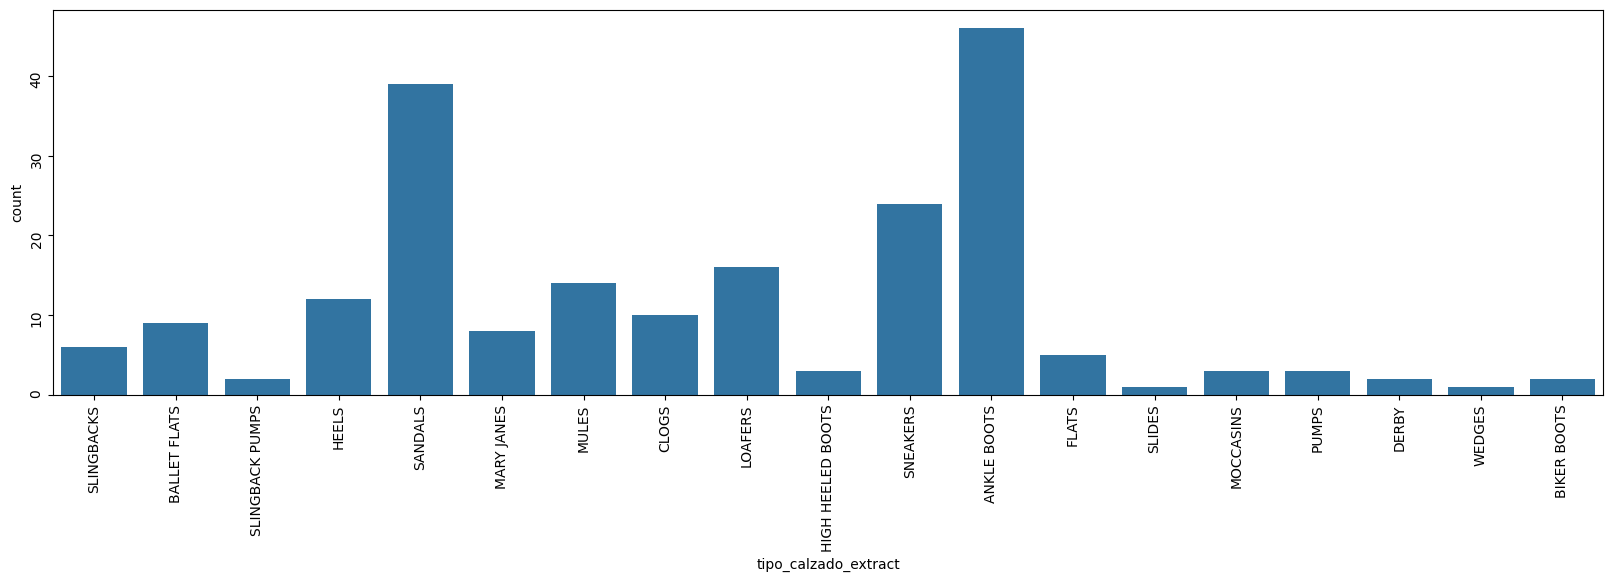

In [2231]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(20,5))
ax = sns.countplot(data=df_zara_woman_shoes, x='tipo_calzado_extract',  ax=ax, legend=True)
ax.tick_params(rotation=90)

In [2232]:
df_zara_woman_shoes.head(2)

,name,description,price,currency,terms,image_downloads,tipo_calzado_extract
0,PEARL HEELED SLINGBACKS,Slingback heels with front pearl detail. Point...,79.9,USD,shoes,"['79d241c5-2dcc-4fc2-8520-3611fe0be740', 'a462...",SLINGBACKS
1,LEATHER BALLET FLATS,Mary Jane style leather ballet flats. Buckled ...,59.9,USD,shoes,"['3c5a4b1d-407b-4683-8489-795e1177aa4a', '769a...",BALLET FLATS


### Reemplazar str (json) en el campo image:_downloads por  lista  de string con el codigo de cada imagen

In [2233]:
def get_images_json_to_list(x:str):
    json_cadena = x.replace("'", "\"")
    lista_imagenes = json.loads(json_cadena)
    return lista_imagenes

# Convertir la columna image_downloads en una lista de strings
df_zara_woman_shoes.loc[:,'image_downloads'] = df_zara_woman_shoes['image_downloads'].apply(get_images_json_to_list)


### Contabilizar el número de imagenes por registro o fila

In [2234]:
# Convertir la columna image_downloads en una lista de strings
df_zara_woman_shoes.loc[:,'total_images'] = df_zara_woman_shoes['image_downloads'].apply(len)

In [2235]:
# Valores únicos de la columna 'total_images'. Se observa el número de imagenes por producto es de 4,6,7 u 8.
df_zara_woman_shoes['total_images'].unique()

array([ 9,  5,  8,  6,  7,  4,  2, 10, 11, 27, 12])

In [2236]:
df_zara_woman_shoes[df_zara_woman_shoes['total_images']==27]

,name,description,price,currency,terms,image_downloads,tipo_calzado_extract,total_images
261,MIXED LEATHER ATHLETIC SNEAKERS,Leather athletic sneakers. Combination of colo...,69.9,USD,shoes,"[30ce5dc1-6739-486b-aad5-0c752ee8a36d, 662223a...",SNEAKERS,27


## Mostrar secuencia de imágenes en base el número de imágenes por producto detectado 2, 4, 5, 6, 7, 8,9,10,11,12,27 para ver si sigue un patron de visualización.

In [2237]:
def show_images(lista_imagenes):
    """ Funcion para mostrar las imagenes"""
    fig, axs = plt.subplots(nrows=1, ncols=len(lista_imagenes), figsize=(30,5))
    for i, image in enumerate(lista_imagenes):
        image_path = "../data/store_zara_data/images/zara/" + str(image) + ".jpg"
        image = Image.open(image_path).convert("RGB")
        axs[i].imshow(image)
        axs[i].axis('off')
    plt.tight_layout() #  ajustar automáticamente el tamaño del gráfico y los márgenes para que se ajuste correctamente a la ventana.
    plt.show()

In [2238]:
df_zara_woman_shoes[df_zara_woman_shoes['total_images']==2]

,name,description,price,currency,terms,image_downloads,tipo_calzado_extract,total_images
44,BUCKLED HEELED SHOES,High heel faux patent leather shoes. Buckled s...,59.9,USD,shoes,"[281d9613-0ad8-4e0b-be88-660ad862c080, ae569dc...",NaN,2


In [ ]:
imagenes_len_2 = df_zara_woman_shoes.loc[44, 'image_downloads']
show_images(imagenes_len_2)

In [2240]:
df_zara_woman_shoes[df_zara_woman_shoes['total_images']==4]

,name,description,price,currency,terms,image_downloads,tipo_calzado_extract,total_images
12,FABRIC MULES,Slingback flats with patent leather effect fin...,49.9,USD,shoes,"[6c553070-a0cb-40b4-9a38-fb2e21de2fe2, 0e5dc73...",MULES,4
36,TEXTURED RUNNING SNEAKERS,Running style sneakers in a combination of tex...,49.9,USD,shoes,"[771cb3c7-9dad-44f7-a89d-a40b1e1bf4b9, 19632c4...",SNEAKERS,4
146,SHINY WOVEN MULES,Flat mules with shiny woven upper. \n\nSole he...,59.9,USD,shoes,"[54c4a9eb-9543-40e4-80d8-7ab0092ecced, 8d5433c...",MULES,4


In [ ]:
imagenes_len_4 = df_zara_woman_shoes.loc[12, 'image_downloads']
show_images(imagenes_len_4)

In [ ]:
# df_zara_woman_shoes[df_zara_woman_shoes['total_images']==5]
imagenes_len_5 = df_zara_woman_shoes.loc[1, 'image_downloads']
show_images(imagenes_len_5)

In [ ]:
#df_zara_woman_shoes[df_zara_woman_shoes['total_images']==6]
imagenes_len_6 = df_zara_woman_shoes.loc[4, 'image_downloads']
show_images(imagenes_len_6)

In [ ]:
#df_zara_woman_shoes[df_zara_woman_shoes['total_images']==7]
imagenes_len_7 = df_zara_woman_shoes.loc[7, 'image_downloads']
show_images(imagenes_len_7)

In [ ]:
#df_zara_woman_shoes[df_zara_woman_shoes['total_images']==8]
imagenes_len_8 = df_zara_woman_shoes.loc[2, 'image_downloads']
show_images(imagenes_len_8)

In [ ]:
#df_zara_woman_shoes[df_zara_woman_shoes['total_images']==9]
imagenes_len_9 = df_zara_woman_shoes.loc[0, 'image_downloads']
show_images(imagenes_len_9)

In [ ]:
#df_zara_woman_shoes[df_zara_woman_shoes['total_images']==10]
imagenes_len_10 = df_zara_woman_shoes.loc[126, 'image_downloads']
show_images(imagenes_len_10)

In [ ]:
#df_zara_woman_shoes[df_zara_woman_shoes['total_images']==11]
imagenes_len_11 = df_zara_woman_shoes.loc[98, 'image_downloads']
show_images(imagenes_len_11)

In [ ]:
#df_zara_woman_shoes[df_zara_woman_shoes['total_images']==12]
imagenes_len_12 = df_zara_woman_shoes.loc[285, 'image_downloads']
show_images(imagenes_len_12)

In [2250]:
df_zara_woman_shoes[df_zara_woman_shoes['total_images']==27]

,name,description,price,currency,terms,image_downloads,tipo_calzado_extract,total_images
261,MIXED LEATHER ATHLETIC SNEAKERS,Leather athletic sneakers. Combination of colo...,69.9,USD,shoes,"[30ce5dc1-6739-486b-aad5-0c752ee8a36d, 662223a...",SNEAKERS,27


In [ ]:
#df_zara_woman_shoes[df_zara_woman_shoes['total_images']==27]
imagenes_len_27 = df_zara_woman_shoes.loc[261, 'image_downloads']
show_images(imagenes_len_27)

In [ ]:
imagenes_index_154 = df_zara_woman_shoes.loc[154, 'image_downloads']
show_images(imagenes_index_154)

In [ ]:
imagenes_index_193 = df_zara_woman_shoes.loc[193, 'image_downloads']
show_images(imagenes_index_193)

In [ ]:
imagenes_index_198 = df_zara_woman_shoes.loc[198, 'image_downloads']
show_images(imagenes_index_198)

----------------------------------------------------------------------------------------------------

In [2255]:
df_zara_woman_shoes.head(2)

,name,description,price,currency,terms,image_downloads,tipo_calzado_extract,total_images
0,PEARL HEELED SLINGBACKS,Slingback heels with front pearl detail. Point...,79.9,USD,shoes,"[79d241c5-2dcc-4fc2-8520-3611fe0be740, a4628bf...",SLINGBACKS,9
1,LEATHER BALLET FLATS,Mary Jane style leather ballet flats. Buckled ...,59.9,USD,shoes,"[3c5a4b1d-407b-4683-8489-795e1177aa4a, 769a6f4...",BALLET FLATS,5


In [2256]:
def show(df:pd.DataFrame,size:str, column:str='total_images'):
    indice = df[df[column]==size].index.tolist()
    print(indice)
    for i in indice:
        show_images(df.loc[i, 'image_downloads'])


In [ ]:
show(df_zara_woman_shoes, 27)

In [2258]:
# Reducimos el tamaño de la lista de imagenes
images_261 = df_zara_woman_shoes.loc[261, 'image_downloads'][6:11]
df_zara_woman_shoes.at[261, 'image_downloads'] = images_261

In [ ]:
show(df_zara_woman_shoes, 12)

In [ ]:
# Reducimos el tamaño de la lista de imagenes
images_285 = df_zara_woman_shoes.loc[285, 'image_downloads'][7:11]
df_zara_woman_shoes.at[285, 'image_downloads'] = images_285

In [2261]:
#show(df_zara_woman_shoes, 11)

In [ ]:
indices_images_11 = [98, 133, 192, 255, 263]

for i in indices_images_11:
    if i==192:
        images_192 = df_zara_woman_shoes.loc[192, 'image_downloads'][4:8]
        df_zara_woman_shoes.at[192, 'image_downloads'] = images_192
    else:
        images_temp = df_zara_woman_shoes.loc[i, 'image_downloads'][6:10]
        df_zara_woman_shoes.at[i, 'image_downloads'] = images_temp


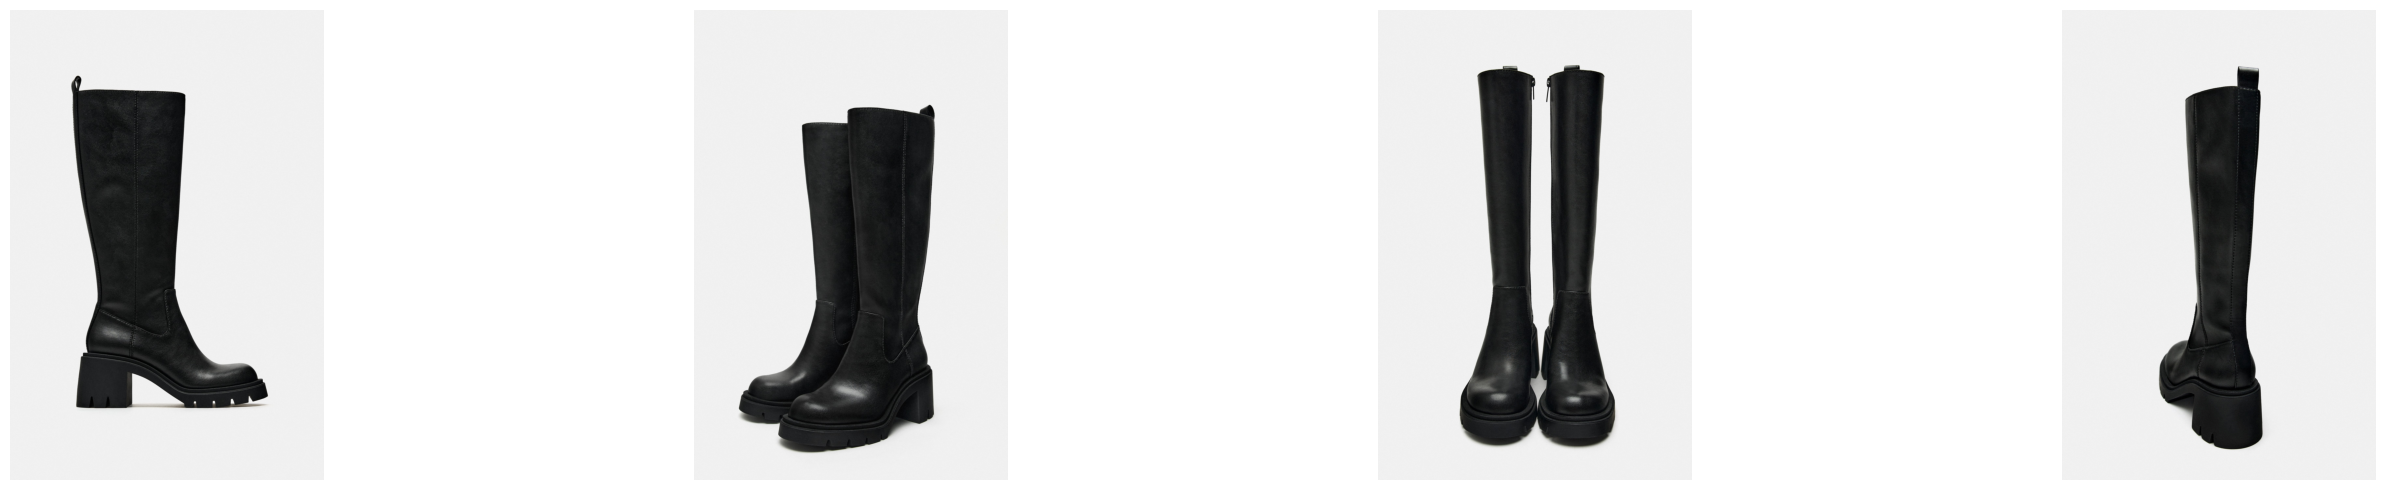

In [2263]:
show_images(df_zara_woman_shoes.loc[192, 'image_downloads'])

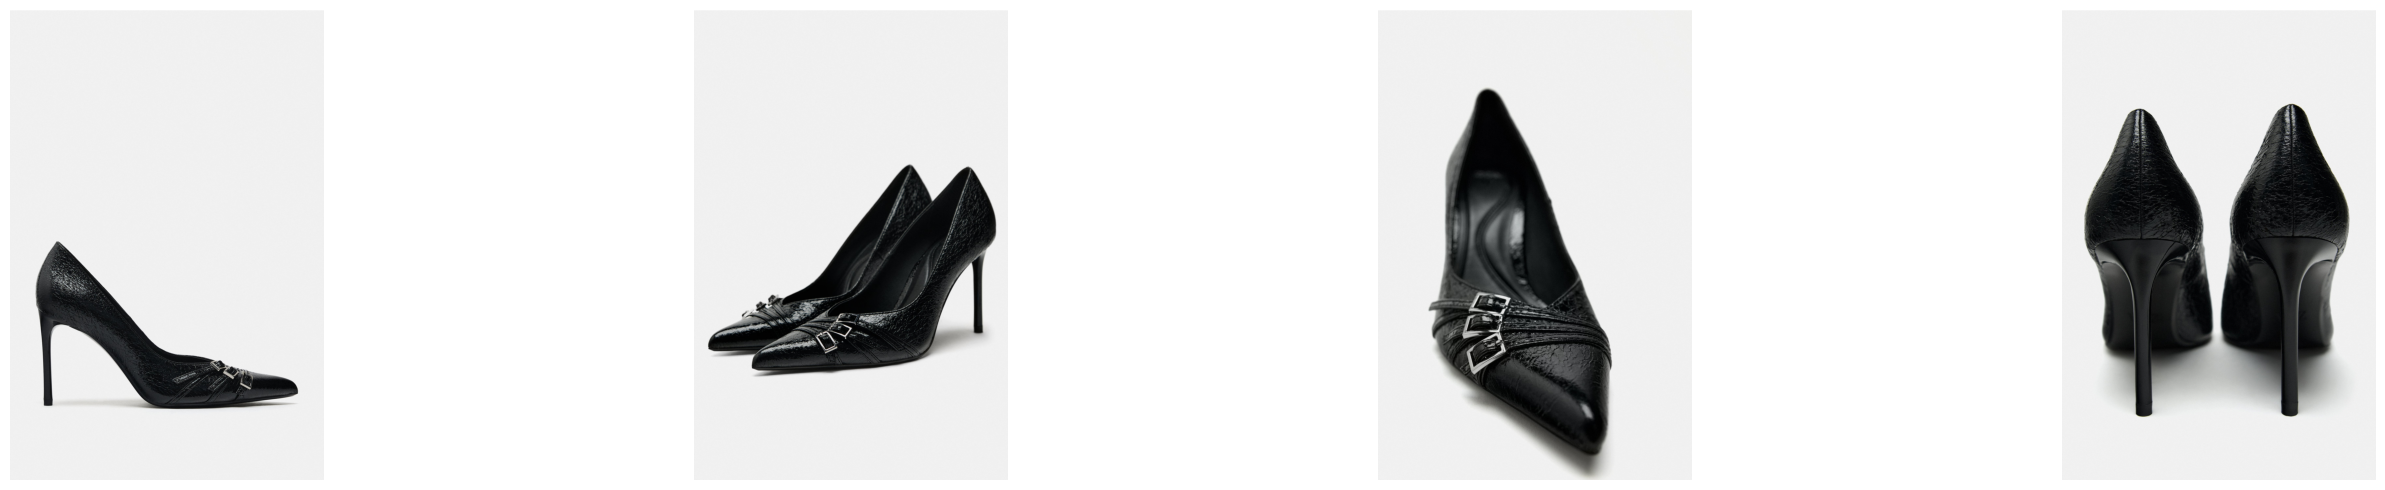

In [2264]:
show_images(df_zara_woman_shoes.loc[98, 'image_downloads'])

In [2265]:
#show(df_zara_woman_shoes, 10)

In [2266]:
indices_images_285 = [64, 126, 144, 148, 176, 222, 235, 239, 243, 270, 272]

for i in indices_images_285:
    if i == 148 or i==235 or i==239 or i==270 or i==272:
        images_temp = df_zara_woman_shoes.loc[i, 'image_downloads'][4:9]
        df_zara_woman_shoes.at[i, 'image_downloads'] = images_temp
    else:
        images_temp = df_zara_woman_shoes.loc[i, 'image_downloads'][5:9]
        df_zara_woman_shoes.at[i, 'image_downloads'] = images_temp


In [ ]:
show_images(df_zara_woman_shoes.loc[64, 'image_downloads'])

In [ ]:
show_images(df_zara_woman_shoes.loc[239, 'image_downloads'])

In [2269]:
#show(df_zara_woman_shoes, 9)

In [2270]:
indices_images_10 = [0, 29, 60, 62, 65, 84, 85, 87, 95, 99, 105, 107, 113, 121, 123, 136, 137, 140, 166, 173, 184, 189, 190, 197, 201, 202, 205, 217, 218, 219, 221, 231, 236, 240, 244, 253, 254, 262, 279, 280, 281, 284]

for i in indices_images_10:
    if i in [0,62,65,85,87,123,140,166,184,217,221]:
        images_temp = df_zara_woman_shoes.loc[i, 'image_downloads'][3:8]
        df_zara_woman_shoes.at[i, 'image_downloads'] = images_temp
    else:
        images_temp = df_zara_woman_shoes.loc[i, 'image_downloads'][4:8]
        df_zara_woman_shoes.at[i, 'image_downloads'] = images_temp


In [ ]:
show_images(df_zara_woman_shoes.loc[0, 'image_downloads'])

In [ ]:
show_images(df_zara_woman_shoes.loc[284, 'image_downloads'])

In [2273]:
#show(df_zara_woman_shoes, 8)

In [2274]:
indices_images_8 = [2, 21, 26, 31, 33, 40, 50, 51, 75, 79, 88, 92, 103, 109, 125, 131, 134, 138, 153, 156, 160, 164, 168, 169, 181, 186, 193, 194, 198, 203, 209, 210, 214, 215, 216, 228, 232, 238, 245, 249, 250, 251, 252, 258, 264]

for i in indices_images_8:
    if i in [31]:
        images_temp = df_zara_woman_shoes.loc[i, 'image_downloads'][1:6]
        df_zara_woman_shoes.at[i, 'image_downloads'] = images_temp
    elif i in [164]:
        images_temp = df_zara_woman_shoes.loc[i, 'image_downloads'][4:8]
        df_zara_woman_shoes.at[i, 'image_downloads'] = images_temp
    elif i in [21,33,88,92,168,186,194,209,245,249]:
        images_temp = df_zara_woman_shoes.loc[i, 'image_downloads'][2:7]
        df_zara_woman_shoes.at[i, 'image_downloads'] = images_temp 
    else:
        images_temp = df_zara_woman_shoes.loc[i, 'image_downloads'][3:8]
        df_zara_woman_shoes.at[i, 'image_downloads'] = images_temp

In [ ]:
show_images(df_zara_woman_shoes.loc[31, 'image_downloads'])

In [ ]:
show_images(df_zara_woman_shoes.loc[164, 'image_downloads'])

In [ ]:
show_images(df_zara_woman_shoes.loc[21, 'image_downloads'])

In [ ]:
show_images(df_zara_woman_shoes.loc[210, 'image_downloads'])

In [2279]:
#show(df_zara_woman_shoes, 7)

In [2280]:
indices_images_7 = [7, 11, 13, 14, 16, 18, 23, 24, 25, 27, 28, 30, 32, 34, 37, 38, 41, 42, 43, 47, 63, 66, 67, 68, 69, 70, 72, 74, 76, 81, 89, 94, 102, 110, 111, 112, 115, 119, 127, 129, 132, 135, 147, 150, 152, 155, 157, 161, 163, 171, 172, 174, 179, 185, 187, 188, 195, 196, 200, 206, 207, 223, 224, 229, 230, 233, 246, 247, 257, 268, 271, 278]

for i in indices_images_7:
    if i in [112]:
        images_temp = df_zara_woman_shoes.loc[i, 'image_downloads'][0:5]
        df_zara_woman_shoes.at[i, 'image_downloads'] = images_temp
    elif i in [13,18,63]:
        images_temp = df_zara_woman_shoes.loc[i, 'image_downloads'][3:7]
        df_zara_woman_shoes.at[i, 'image_downloads'] = images_temp
    else:
        images_temp = df_zara_woman_shoes.loc[i, 'image_downloads'][2:7]
        df_zara_woman_shoes.at[i, 'image_downloads'] = images_temp

In [ ]:
show_images(df_zara_woman_shoes.loc[47, 'image_downloads'])

In [ ]:
show_images(df_zara_woman_shoes.loc[112, 'image_downloads'])

In [ ]:
show_images(df_zara_woman_shoes.loc[63, 'image_downloads'])

In [2284]:
#show(df_zara_woman_shoes, 6)

In [ ]:
indices_images_6 = [4, 8, 10, 22, 45, 48, 53, 54, 56, 58, 61, 71, 73, 78, 82, 83, 90, 96, 97, 100, 101, 108, 116, 117, 118, 120, 122, 128, 139, 141, 142, 145, 149, 151, 154, 170, 175, 177, 178, 180, 182, 191, 199, 204, 208, 211, 225, 226, 237, 248, 256, 259, 266, 267, 282]

for i in indices_images_6:
    if i in [73,120,122,128,139,175,237]:
        images_temp = df_zara_woman_shoes.loc[i, 'image_downloads'][2:6]
        df_zara_woman_shoes.at[i, 'image_downloads'] = images_temp
    elif i in [48,154,180,191,199,204]:
        images_temp = df_zara_woman_shoes.loc[i, 'image_downloads']
        df_zara_woman_shoes.at[i, 'image_downloads'] = images_temp
    else:
        images_temp = df_zara_woman_shoes.loc[i, 'image_downloads'][1:6]
        df_zara_woman_shoes.at[i, 'image_downloads'] = images_temp

In [ ]:
show_images(df_zara_woman_shoes.loc[73, 'image_downloads'])

In [ ]:
show_images(df_zara_woman_shoes.loc[48, 'image_downloads'])

In [ ]:
show_images(df_zara_woman_shoes.loc[61, 'image_downloads'])

In [2289]:
#show(df_zara_woman_shoes, 5)

In [2290]:
indices_images_5 = [1, 3, 5, 6, 9, 15, 17, 19, 20, 35, 39, 46, 49, 52, 55, 57, 59, 77, 80, 86, 91, 93, 104, 106, 114, 124, 130, 143, 158, 159, 162, 165, 167, 183, 212, 213, 220, 227, 234, 241, 242, 260, 265, 269, 283, 286]

for i in indices_images_5:
    if i in [5,15,17,20,49,93,283]:
        images_temp = df_zara_woman_shoes.loc[i, 'image_downloads'][1:5]
        df_zara_woman_shoes.at[i, 'image_downloads'] = images_temp
    else:
        images_temp = df_zara_woman_shoes.loc[i, 'image_downloads']
        df_zara_woman_shoes.at[i, 'image_downloads'] = images_temp


In [ ]:
show_images(df_zara_woman_shoes.loc[5, 'image_downloads'])

In [ ]:
show_images(df_zara_woman_shoes.loc[39, 'image_downloads'])

In [ ]:
show(df_zara_woman_shoes, 4)

In [2294]:
indices_images_4 = [12, 36, 146]

for i in indices_images_4:
    if i in [12]:
        images_temp = df_zara_woman_shoes.loc[i, 'image_downloads'][1:4]
        df_zara_woman_shoes.at[i, 'image_downloads'] = images_temp
    else:
        images_temp = df_zara_woman_shoes.loc[i, 'image_downloads']
        df_zara_woman_shoes.at[i, 'image_downloads'] = images_temp

In [ ]:
show_images(df_zara_woman_shoes.loc[12, 'image_downloads'])

In [2296]:
#show(df_zara_woman_shoes, 2)

In [2297]:
indices_images_2 = [44]

for i in indices_images_2:
    images_temp = df_zara_woman_shoes.loc[i, 'image_downloads'][0:1]
    df_zara_woman_shoes.at[i, 'image_downloads'] = images_temp


In [2298]:
# Recontamos de nuevo la columna image_downloads
df_zara_woman_shoes.loc[:,'total_images_2'] = df_zara_woman_shoes['image_downloads'].apply(len)

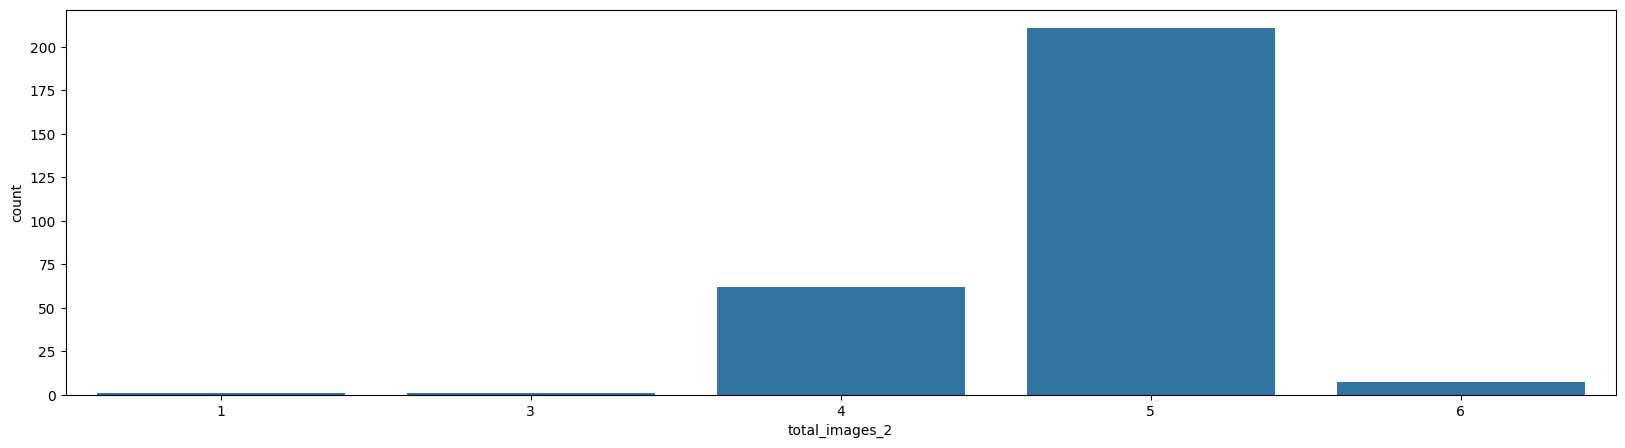

In [2299]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(20,5))
ax = sns.countplot(data=df_zara_woman_shoes, x='total_images_2',  ax=ax, legend=True)

In [2300]:
df_zara_woman_shoes['total_images_2'].unique()

array([5, 4, 3, 1, 6])

In [ ]:
show(df_zara_woman_shoes, 4,'total_images_2')

## Selección de vista isométrica como única imagen de producto.
Observamos que la posiciónn de la vista isometrica en el calzado de mujer es variable.

In [2307]:
df_zara_woman_shoes['iso_image'] = ''

for index, row in df_zara_woman_shoes.iterrows():
     if index == 12:
        df_zara_woman_shoes.loc[index, 'iso_image'] = row['image_downloads'][1]
     elif index == 44:
        df_zara_woman_shoes.loc[index, 'iso_image'] = row['image_downloads'][0]
     elif index == 145:
        df_zara_woman_shoes.loc[index, 'iso_image'] = row['image_downloads'][2]
     else:
        df_zara_woman_shoes.loc[index, 'iso_image'] = row['image_downloads'][1]

In [2309]:
df_zara_woman_shoes['iso_image'].isnull().sum()

np.int64(0)

In [2310]:
df_zara_woman_shoes.shape

(282, 10)

In [2311]:
def show_images17x17(lista_imagenes):
    """ Funcion para mostrar las imagenes"""
    fig, axs = plt.subplots(nrows=17, ncols=17, figsize=(10,10))
    for i in range(17):
        for j in range(17):
            if i * 17 + j < len(lista_imagenes):
                image_path = "../data/store_zara_data/images/zara/" + str(lista_imagenes[i * 17 + j]) + ".jpg"
                image = Image.open(image_path).convert("RGB")
                axs[i, j].imshow(image)
                axs[i, j].axis('off')
    plt.tight_layout()
    plt.show()


In [ ]:
total_iso_images =df_zara_woman_shoes['iso_image'].to_list()
show_images17x17(total_iso_images)